In [10]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

## Generate Image Data - 64x64

Taking an input image provided via source path or using a generic circle and creating a 64x64 binary test image for our tb

In [11]:
def generate_test_data_from_image():
    """
    Reads the source image, converts it to binarized 64x64 data.
    If the image is not found, falls back to a synthetic circle.
    Writes the interleaved imager_test_data.hex file.
    """
    image_path = "/LinuxRAID/home/aokieh1/projects/open_dvs_digital/fver/spi_async_fifo_reg/python/source_image.png"
    # 1. Load the image OR generate synthetic fallback
    if os.path.exists(image_path):
        print(f"Loading '{image_path}'...")
        # Convert to Grayscale ('L') and force to 64x64
        img_pil = Image.open(image_path).convert('L').resize((64, 64))
        # Binarize: Pixels > 128 become 1 (White/ON), otherwise 0 (Black/OFF)
        img = (np.array(img_pil) > 128).astype(int)
    else:
        print(f"[WARNING] Could not find image at: {image_path}")
        print(" -> Falling back to synthetic 64x64 circle pattern.")
        img = np.zeros((64, 64), dtype=int)
        for y in range(64):
            for x in range(64):
                if (x - 32)**2 + (y - 32)**2 < 20**2:
                    img[y, x] = 1
            
    # 2. Separate into ON events (pixels == 1) and OFF events (pixels == 0)
    on_events = (img == 1).astype(int)
    off_events = (img == 0).astype(int)
    
    # 3. Interleave rows and write to hex file for Verilog
    filename = "papa_test_data_64x64.hex"
    with open(filename, "w") as f:
        for row in range(64):
            # Pack 64 pixels into a 64-bit integer
            on_val = 0
            off_val = 0
            for col in range(64):
                on_val  |= (int(on_events[row, col]) << (63 - col))
                off_val |= (int(off_events[row, col]) << (63 - col))
                
            f.write(f"{on_val:016X}\n")
            f.write(f"{off_val:016X}\n")
            
    print(f"Successfully generated 128 rows of 64-bit hex data to '{filename}'!")

    # Return the generated arrays so the parser can compare them later
    return img, on_events, off_events

## Post TB Processing (64x64)

Here we parse the data that was generated by the tb and compare it to the original input

In [12]:
def parse_data_from_roic(original_img, expected_on, expected_off):
    """
    Parses sim_output_64x64.txt, reconstructs the arrays, compares them 
    against the expected inputs, and displays the 2x2 verification plot.
    """
    parsed_on = np.zeros((64, 64), dtype=int)
    parsed_off = np.zeros((64, 64), dtype=int)
    
    on_row_idx = 0
    off_row_idx = 0
    
    filepath = "sim_output_64x64.txt" # generated by roic_top_tb_64.sv

    if not os.path.exists(filepath):
        print(f"\nError: '{filepath}' not found.")
        print("Make sure you run the SystemVerilog ROIC simulation first!")
        return
        
    print(f"Parsing '{filepath}'...")
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
                
            # Read the 17-character hex string as a base-16 integer
            val = int(line, 16)
            
            # Shift and mask to decouple the event flag and the array data
            event_flag = (val >> 64) & 0x3  # The top 2 bits
            data_64bit = val & 0xFFFFFFFFFFFFFFFF  # The bottom 64 bits
            
            # Unpack the 64-bit integer back into an array of 64 individual pixels
            row_pixels = [(data_64bit >> (63 - col)) & 1 for col in range(64)]
            
            if event_flag == 2:   # 2'b10 (ON DETECT)
                if on_row_idx < 64:
                    parsed_on[on_row_idx, :] = row_pixels
                    on_row_idx += 1
                    
            elif event_flag == 1: # 2'b01 (OFF DETECT)
                if off_row_idx < 64:
                    parsed_off[off_row_idx, :] = row_pixels
                    off_row_idx += 1

    print(f" -> Captured {on_row_idx} ON rows and {off_row_idx} OFF rows from RTL output.")

    # =======================================================================
    # AUTOMATED DATA INTEGRITY CHECK
    # =======================================================================
    on_match = np.array_equal(expected_on, parsed_on)
    off_match = np.array_equal(expected_off, parsed_off)
    
    print("\n==========================================================")
    if on_match and off_match:
        print(" [SUCCESS] ROIC OUTPUT PERFECTLY MATCHES ORIGINAL IMAGE!")
    else:
        print(" [FATAL ERROR] ROIC OUTPUT MISMATCH DETECTED!")
        if not on_match: print("  -> ON events do not match.")
        if not off_match: print("  -> OFF events do not match.")
    print("==========================================================\n")

    # =======================================================================
    # RECONSTRUCT & PLOT
    # =======================================================================
    # Reconstruct the image (ON events perfectly represent the BW image's '1's)
    reconstructed = parsed_on | (parsed_off * 0)

    fig, axes = plt.subplots(2, 2, figsize=(11, 11))
    fig.canvas.manager.set_window_title('ROIC Digital Twin Verification')
    
    axes[0, 0].imshow(original_img, cmap='gray')
    axes[0, 0].set_title("1. Original Image (Input)", fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(parsed_on, cmap='gray')
    title_on = f"2. Parsed ON Events (Match: {'YES' if on_match else 'NO'})"
    axes[0, 1].set_title(title_on, color='green' if on_match else 'red', fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(reconstructed, cmap='gray')
    axes[1, 0].set_title("3. ROIC Reconstructed Output", fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(parsed_off, cmap='gray')
    title_off = f"4. Parsed OFF Events (Match: {'YES' if off_match else 'NO'})"
    axes[1, 1].set_title(title_off, color='green' if off_match else 'red', fontsize=14, fontweight='bold')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

In [13]:
# 1. Generate the stimulus file (run this BEFORE Verilog Simulation)
img, expected_on, expected_off = generate_test_data_from_image()

Loading '/LinuxRAID/home/aokieh1/projects/open_dvs_digital/fver/spi_async_fifo_reg/python/source_image.png'...
Successfully generated 128 rows of 64-bit hex data to 'papa_test_data_64x64.hex'!


Parsing 'sim_output_64x64.txt'...
 -> Captured 64 ON rows and 64 OFF rows from RTL output.

 [SUCCESS] ROIC OUTPUT PERFECTLY MATCHES ORIGINAL IMAGE!



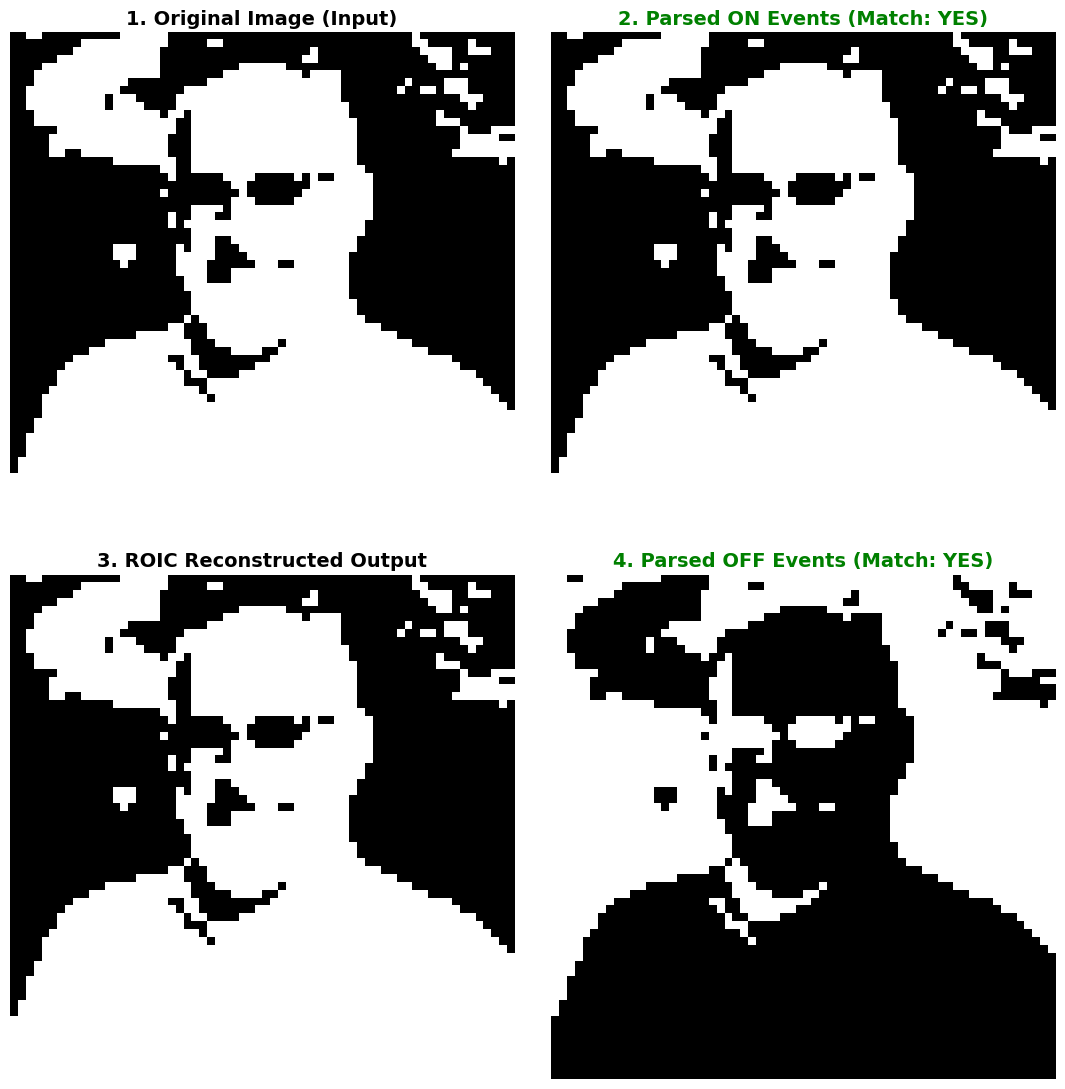

In [14]:
# 2. Parse the output and compare (run this AFTER Verilog Simulation)
if img is not None:
    parse_data_from_roic(img, expected_on, expected_off)

## Converting an image to 128 x 128

Here we convert a sample image that is 300x300 RGB --> 128x128 binary BW. This is next used to pass through our roic_top_tb which operates on two 64x128 ROICs which we will use to simulate a 128x128 imager.

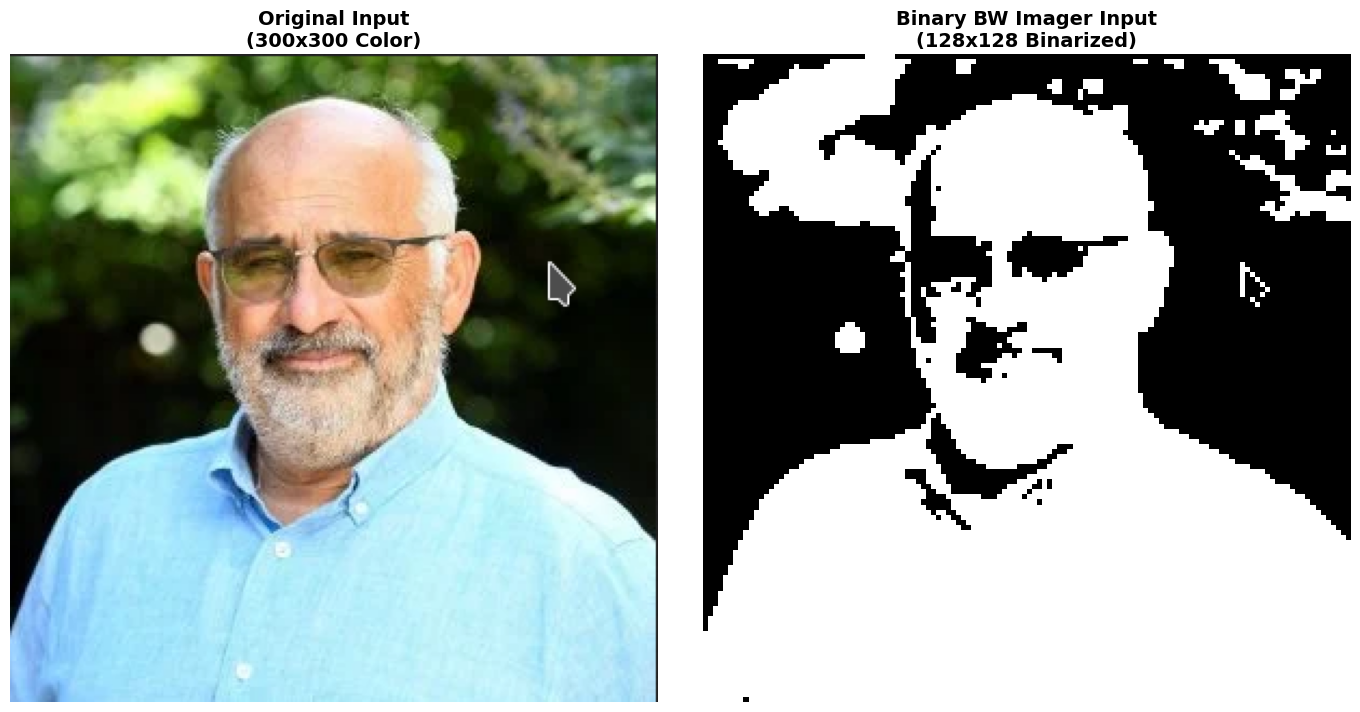

In [6]:
def plot_original_vs_binary(source_path, target_size=(128, 128), threshold=128):
    """
    Displays a 1x2 subplot of the original color image and the binarized version.
    """
    if not os.path.exists(source_path):
        print(f"Error: Source image not found at {source_path}")
        return

    # 1. Load the original color image for display
    original_img = Image.open(source_path)

    # 2. Process for the Imager: Grayscale -> Resize -> Binarize
    # Mode 'L' is 8-bit pixels, black and white
    # LANCZOS is used for high-quality downsampling
    img_processed = original_img.convert('L').resize(target_size, resample=Image.LANCZOS)
    
    # Binarize the array (Pixels > 128 become 1, others 0)
    bw_array = (np.array(img_processed) > threshold).astype(int)

    # 3. Create the subplot
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    fig.canvas.manager.set_window_title('Imager Input Verification')

    # Left Plot: Original Image
    axes[0].imshow(original_img)
    axes[0].set_title(f"Original Input\n({original_img.size[0]}x{original_img.size[1]} Color)", 
                      fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # Right Plot: Binarized BW Image
    # Using 'gray' colormap to show 0 as black and 1 as white
    axes[1].imshow(bw_array, cmap='gray')
    axes[1].set_title(f"Binary BW Imager Input\n({target_size[0]}x{target_size[1]} Binarized)", 
                      fontsize=14, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Path to your source image
path = "/LinuxRAID/home/aokieh1/projects/open_dvs_digital/fver/spi_async_fifo_reg/python/papa.png"
plot_original_vs_binary(path)

## Generate Image Data - 128x128

Taking an input image provided via source path or using a generic circle and creating a 128x128 binary test image for our tb

In [7]:
def generate_test_data_from_image_128x128():
    """
    Reads the source image, visualizes it against a 128x128 binarized version,
    and writes the interleaved imager_test_data_128x128.hex file.
    The hex file contains 256 lines: 128 for the Top ROIC, 128 for the Bottom ROIC.
    """
    image_path = "/LinuxRAID/home/aokieh1/projects/open_dvs_digital/fver/spi_async_fifo_reg/python/papa.png"
    target_size = (128, 128)
    threshold = 128
    
    # =======================================================================
    # 1. LOAD, PROCESS, AND VISUALIZE
    # =======================================================================
    if os.path.exists(image_path):
        print(f"Loading '{image_path}'...")
        original_img = Image.open(image_path)
        
        # Process for the Imager: Grayscale -> Resize (128x128) -> Binarize
        img_processed = original_img.convert('L').resize(target_size, resample=Image.LANCZOS)
        img = (np.array(img_processed) > threshold).astype(int)
        
        # Create the 1x2 comparison subplot you requested
        fig, axes = plt.subplots(1, 2, figsize=(14, 7))
        fig.canvas.manager.set_window_title('Imager Input Verification (128x128)')
        
        axes[0].imshow(original_img)
        axes[0].set_title(f"Original Input\n({original_img.size[0]}x{original_img.size[1]} Color)", 
                          fontsize=14, fontweight='bold')
        axes[0].axis('off')
        
        axes[1].imshow(img, cmap='gray')
        axes[1].set_title(f"Binary BW Imager Input\n({target_size[0]}x{target_size[1]} Binarized)", 
                          fontsize=14, fontweight='bold')
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
        
    else:
        print(f"[WARNING] Could not find image at: {image_path}")
        print(" -> Falling back to synthetic 128x128 circle pattern.")
        img = np.zeros((128, 128), dtype=int)
        for y in range(128):
            for x in range(128):
                # Center the circle at x=64, y=64
                if (x - 64)**2 + (y - 64)**2 < 40**2:
                    img[y, x] = 1
                    
    # =======================================================================
    # 2. EVENT SEPARATION & BIT PACKING
    # =======================================================================
    on_events = (img == 1).astype(int)
    off_events = (img == 0).astype(int)
    
    filename = "papa_test_data_128x128.hex"
    
    with open(filename, "w") as f:
        # --- TILE 1: TOP ROIC (Rows 0 to 63) ---
        for row in range(64):
            on_data_128, off_data_128 = 0, 0
            for col in range(128):
                on_data_128  |= (int(on_events[row, col]) << (127 - col))
                off_data_128 |= (int(off_events[row, col]) << (127 - col))
            
            # Pack: {128-bit data, 2-bit event mode, 6-bit row addr (0-63)}
            on_packet  = (on_data_128 << 8) | (2 << 6) | row
            off_packet = (off_data_128 << 8) | (1 << 6) | row
                
            f.write(f"{on_packet:034X}\n")
            f.write(f"{off_packet:034X}\n")

        # --- TILE 2: BOTTOM ROIC (Rows 64 to 127) ---
        for row in range(64, 128):
            on_data_128, off_data_128 = 0, 0
            for col in range(128):
                on_data_128  |= (int(on_events[row, col]) << (127 - col))
                off_data_128 |= (int(off_events[row, col]) << (127 - col))
            
            # The Bottom ROIC still only has a 6-bit address counter (0-63).
            # So we must map the global image row (64-127) back to the ROIC's local address (0-63).
            local_row_addr = row - 64
            
            # Pack: {128-bit data, 2-bit event mode, 6-bit local row addr (0-63)}
            on_packet  = (on_data_128 << 8) | (2 << 6) | local_row_addr
            off_packet = (off_data_128 << 8) | (1 << 6) | local_row_addr
                
            f.write(f"{on_packet:034X}\n")
            f.write(f"{off_packet:034X}\n")
            
    print(f"Successfully generated 256 lines of 136-bit hex data to '{filename}'!")

    return img, on_events, off_events

# generate_test_data_from_image_128x128()

In [15]:
def parse_data_from_roic_128x128(original_img, expected_on, expected_off):
    """
    Parses sim_output_128x128.txt, unpacks the 137-bit packets using the embedded 7-bit 
    global row_addr, reconstructs the arrays, and displays the 2x2 verification visualization.
    """
    # 1. Initialize empty 128x128 arrays to hold the fully stitched image
    parsed_on = np.zeros((128, 128), dtype=int)
    parsed_off = np.zeros((128, 128), dtype=int)
    
    rows_captured = 0
    
    # 2. Point to the correct output file generated by the Verilog TB
    filepath = "/LinuxRAID/home/aokieh1/projects/open_dvs_digital/fver/roic/python/sim_output_128x128.txt"
    
    # Fallback to current directory if the absolute path fails (e.g., if you move the scripts)
    if not os.path.exists(filepath):
        filepath = "sim_output_128x128.txt"
        
    if not os.path.exists(filepath):
        print(f"\nError: '{filepath}' not found.")
        print("Make sure you run the SystemVerilog ROIC simulation first!")
        return
        
    print(f"Parsing '{filepath}'...")
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
                
            # Read the 35-character hex string as a base-16 integer
            val = int(line, 16)
            
            # 3. Unpack the 137-bit packet based on the updated Verilog TB structure
            # {array_col_out[127:0], event_flag[1:0], sim_global_row[6:0]}
            global_row_addr = val & 0x7F                         # Bottom 7 bits (0-127)
            event_flag      = (val >> 7) & 0x3                   # Next 2 bits
            data_128bit     = (val >> 9) & ((1 << 128) - 1)      # Top 128 bits
            
            # Extract the 128 individual pixels for this row
            row_pixels = [(data_128bit >> (127 - col)) & 1 for col in range(128)]
            
            # 4. Use the embedded global_row_addr to place the data in the correct Y coordinate!
            if event_flag == 2 and global_row_addr < 128:   # ON DETECT
                parsed_on[global_row_addr, :] = row_pixels
                rows_captured += 1
            elif event_flag == 1 and global_row_addr < 128: # OFF DETECT
                parsed_off[global_row_addr, :] = row_pixels
                rows_captured += 1

    print(f" -> Captured {rows_captured} total rows from RTL output.")

    # =======================================================================
    # AUTOMATED DATA INTEGRITY CHECK
    # =======================================================================
    on_match = np.array_equal(expected_on, parsed_on)
    off_match = np.array_equal(expected_off, parsed_off)
    
    print("\n========================================================================")
    if on_match and off_match:
        print(" [SUCCESS] 128x128 TILED ROIC OUTPUT PERFECTLY MATCHES ORIGINAL IMAGE!")
    else:
        print(" [FATAL ERROR] 128x128 TILED ROIC OUTPUT MISMATCH DETECTED!")
        if not on_match: print("  -> ON events do not match.")
        if not off_match: print("  -> OFF events do not match.")
    print("========================================================================\n")

    # =======================================================================
    # RECONSTRUCT & VISUALIZE
    # =======================================================================
    reconstructed = parsed_on | (parsed_off * 0)

    # Use a square figure size since the image is now 128x128
    fig, axes = plt.subplots(2, 2, figsize=(11, 11)) 
    fig.canvas.manager.set_window_title('ROIC Digital Twin Verification (128x128 Tiled)')
    
    axes[0, 0].imshow(original_img, cmap='gray')
    axes[0, 0].set_title("1. Original Image (Input)", fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(parsed_on, cmap='gray')
    title_on = f"2. Parsed ON Events (Match: {'YES' if on_match else 'NO'})"
    axes[0, 1].set_title(title_on, color='green' if on_match else 'red', fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(reconstructed, cmap='gray')
    axes[1, 0].set_title("3. ROIC Reconstructed Output", fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(parsed_off, cmap='gray')
    title_off = f"4. Parsed OFF Events (Match: {'YES' if off_match else 'NO'})"
    axes[1, 1].set_title(title_off, color='green' if off_match else 'red', fontsize=14, fontweight='bold')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

# parse_data_from_roic_128x128(img, expected_on, expected_off)

Loading '/LinuxRAID/home/aokieh1/projects/open_dvs_digital/fver/spi_async_fifo_reg/python/papa.png'...


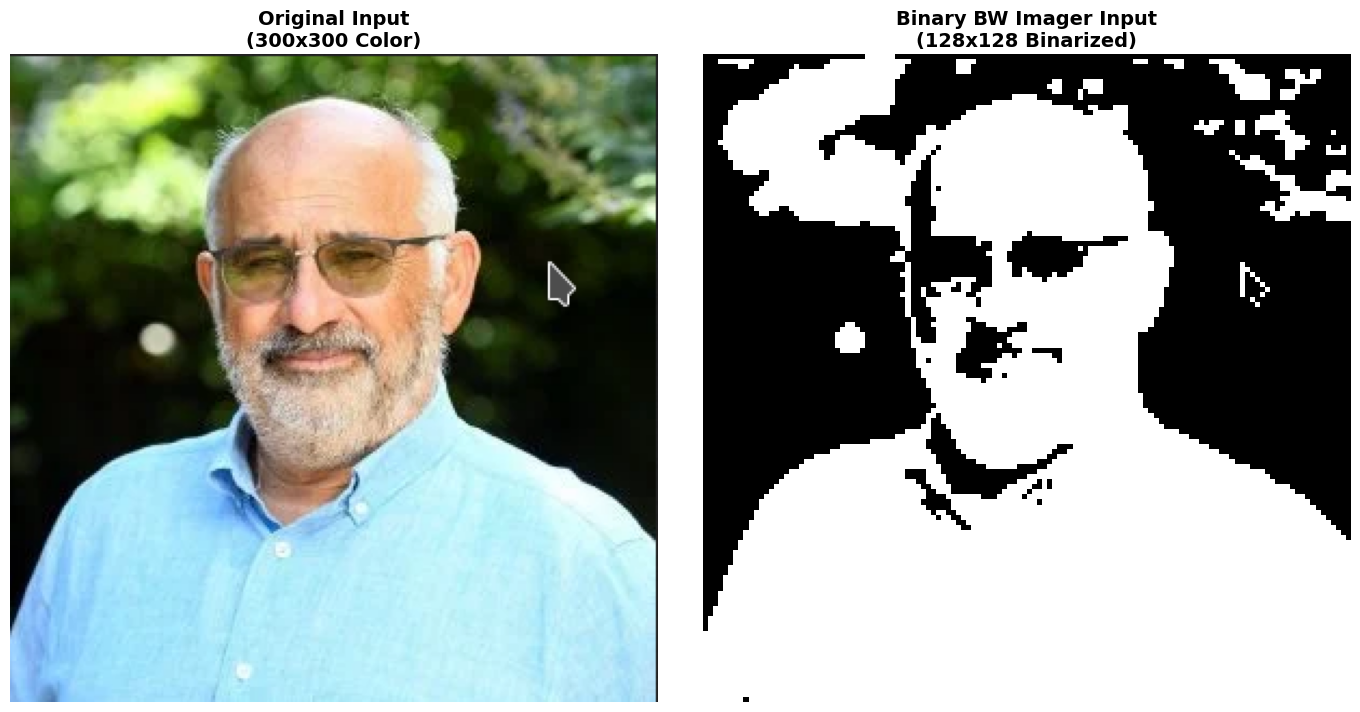

Successfully generated 256 lines of 136-bit hex data to 'papa_test_data_128x128.hex'!


In [19]:
# 1. Generate 128x128 stimulus
img, expected_on, expected_off = generate_test_data_from_image_128x128()

Parsing '/LinuxRAID/home/aokieh1/projects/open_dvs_digital/fver/roic/python/sim_output_128x128.txt'...
 -> Captured 512 total rows from RTL output.

 [SUCCESS] 128x128 TILED ROIC OUTPUT PERFECTLY MATCHES ORIGINAL IMAGE!



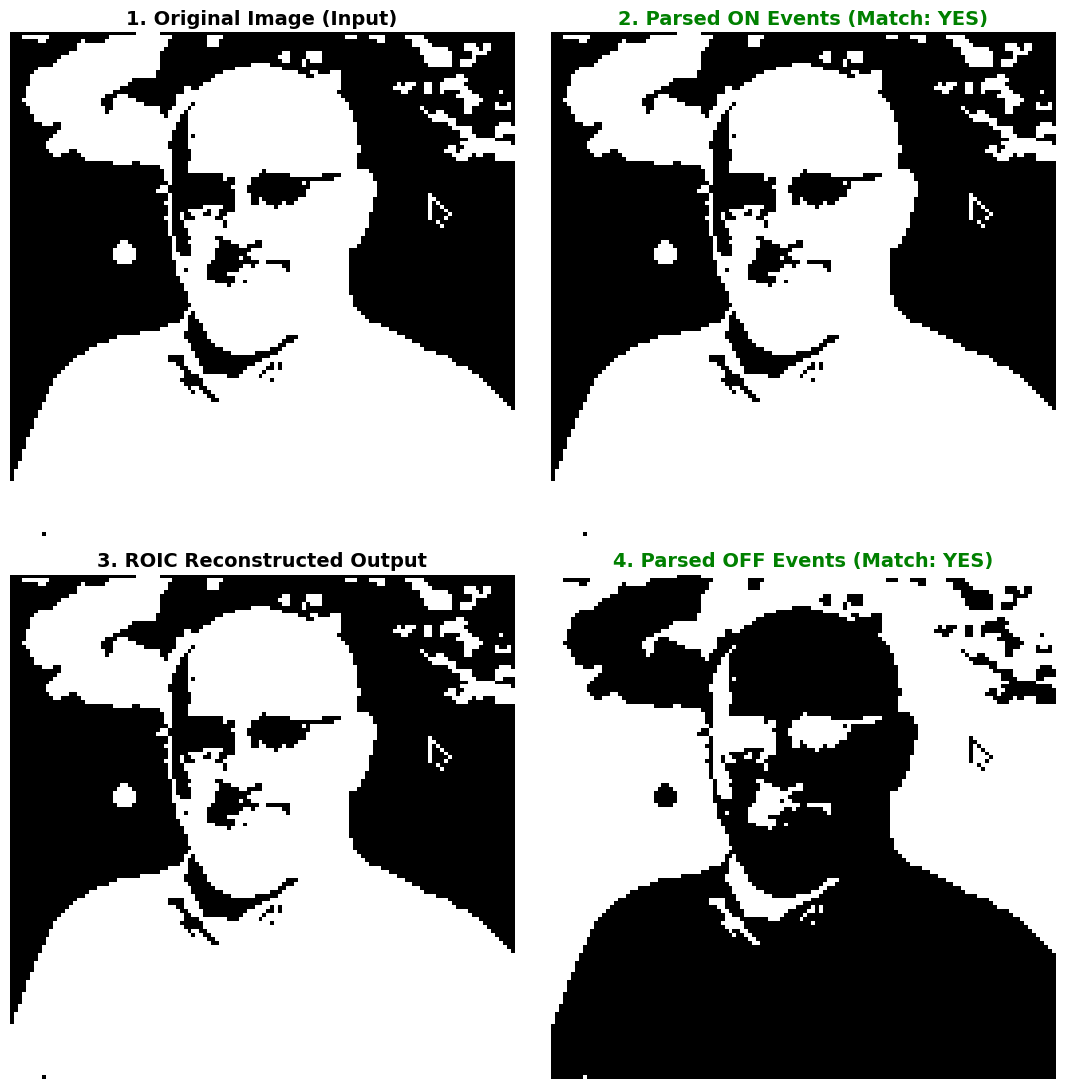

In [20]:
# 2. Parse output from SystemVerilog (after running TB)
parse_data_from_roic_128x128(img, expected_on, expected_off)

## Operational Speed of This Imager


For a given program_bits setting, each row must be processed in three sequential modes: detect_on, detect_off, and pixel_rst. As a result, the total time required to service a single row is three times the programmed duration. For example, when program_bits = 1 µs, a full row readout requires 3 µs (1 µs per mode).

Since a complete frame consists of 64 rows, the total frame time scales linearly with the programmed per-mode duration.

        Frame Time = program_time x 3 (num of modes) x 64 (num of rows)

The log-scale plots below illustrate both the total frame readout time and the corresponding refresh rate as a function of the programmable timing parameter.

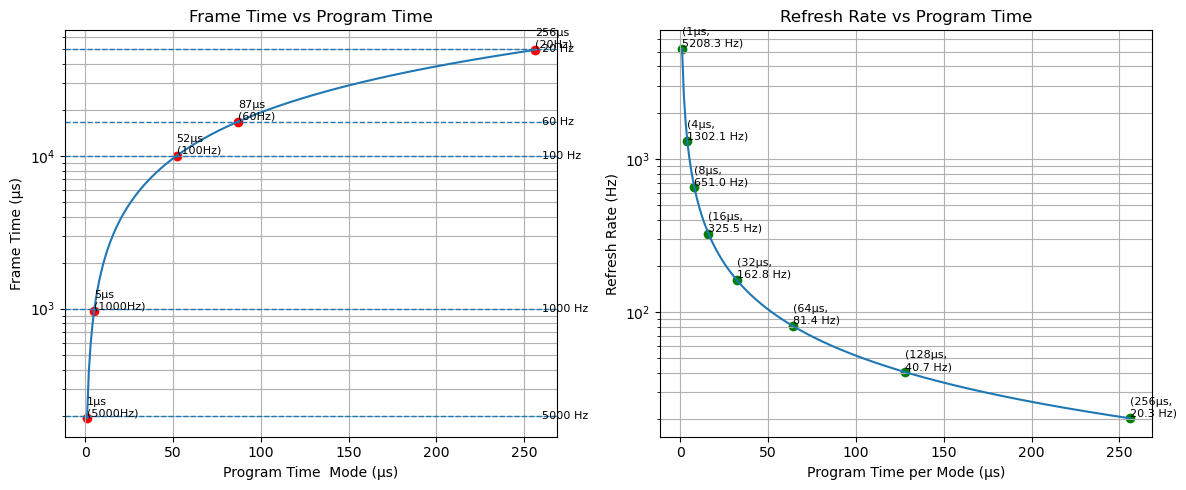

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Programmable time per mode (in microseconds)
t_us = np.linspace(1, 256, 256)

# Constants
modes_per_row = 3
rows_per_frame = 64

# Frame time
frame_time_us = t_us * modes_per_row * rows_per_frame
frame_time_s = frame_time_us * 1e-6

# Refresh rate
refresh_rate = 1 / frame_time_s

# -----------------------------
# Target FPS → Frame Time
# -----------------------------
target_fps = np.array([20, 60, 100, 1000, 5000])
target_frame_us = 1e6 / target_fps

# Find closest programmable settings
closest_t = []
closest_frame = []

for target in target_frame_us:
    idx = np.argmin(np.abs(frame_time_us - target))
    closest_t.append(t_us[idx])
    closest_frame.append(frame_time_us[idx])

closest_t = np.array(closest_t)
closest_frame = np.array(closest_frame)

# -----------------------------
# Highlight points (powers of 2-ish)
# -----------------------------
highlight_t = np.array([1, 4, 8, 16, 32, 64, 128, 256])
highlight_frame_us = highlight_t * modes_per_row * rows_per_frame
highlight_refresh = 1 / (highlight_frame_us * 1e-6)

# -----------------------------
# Plotting
# -----------------------------
plt.figure(figsize=(12, 5))

# ===== LEFT: Frame Time =====
plt.subplot(1, 2, 1)
plt.plot(t_us, frame_time_us)

plt.yscale('log')

# Target FPS lines
for fps, ft in zip(target_fps, target_frame_us):
    plt.axhline(ft, linestyle='--', linewidth=1)
    plt.text(260, ft, f"{fps} Hz", va='center', fontsize=8)

# Closest points
plt.scatter(closest_t, closest_frame, color='red')

for t, ft, fps in zip(closest_t, closest_frame, target_fps):
    plt.text(
        t, ft,
        f"{int(t)}µs\n({fps}Hz)",
        fontsize=8,
        ha='left',
        va='bottom'
    )

plt.xlabel("Program Time  Mode (µs)")
plt.ylabel("Frame Time (µs)")
plt.title("Frame Time vs Program Time")
plt.grid(True, which="both")


# ===== RIGHT: Refresh Rate =====
plt.subplot(1, 2, 2)
plt.plot(t_us, refresh_rate)

plt.yscale('log')

# Highlight points
plt.scatter(highlight_t, highlight_refresh, color='green')

for x, y in zip(highlight_t, highlight_refresh):
    plt.text(
        x, y,
        f"({int(x)}µs,\n{y:.1f} Hz)",
        fontsize=8,
        ha='left',
        va='bottom'
    )

plt.xlabel("Program Time per Mode (µs)")
plt.ylabel("Refresh Rate (Hz)")
plt.title("Refresh Rate vs Program Time")
plt.grid(True, which="both")

plt.tight_layout()
plt.show()